<a href="https://colab.research.google.com/github/taofiqsulayman/collab-playground/blob/main/Growth_Assay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
import numpy as np

In [56]:
file_path = './Assay_40.xlsx'  # Replace with your file path
df = pd.read_excel(file_path)

df['Time'] = df['Time'].str.replace(' mins', '').astype(int)

In [57]:
print(df.head())  # show the first few rows
print(df.info())  # show data types and summary stats
print(df.describe())  # show summary stats

   Time  Negative control   Newmann  S. argenteus    FSA084     EHO40  \
0     0         -0.006000  0.085333      0.078333  0.088000  0.080000   
1    10          0.004333  0.125333      0.138667  0.152000  0.099000   
2    20          0.004333  0.146333      0.166000  0.185000  0.121000   
3    30          0.004333  0.169667      0.182333  0.199333  0.151667   
4    40          0.006333  0.211667      0.243000  0.266333  0.185667   

     FBA12B   BSA107B    EHA38B    BSO85B    BSA89B    BSO93B   BSO107B  \
0  0.065000  0.074000  0.077000  0.103667  0.066667  0.081000  0.046667   
1  0.106667  0.139667  0.149333  0.118333  0.106333  0.135000  0.114667   
2  0.131667  0.175000  0.189333  0.130000  0.130000  0.166333  0.151000   
3  0.157667  0.201000  0.208333  0.104333  0.157000  0.187000  0.167667   
4  0.209667  0.259667  0.259000  0.117667  0.217000  0.242667  0.207333   

      EHA23    BSO66B   BSA100B     BSO35  
0  0.066333  0.079667  0.085667  0.028667  
1  0.080333  0.110333 

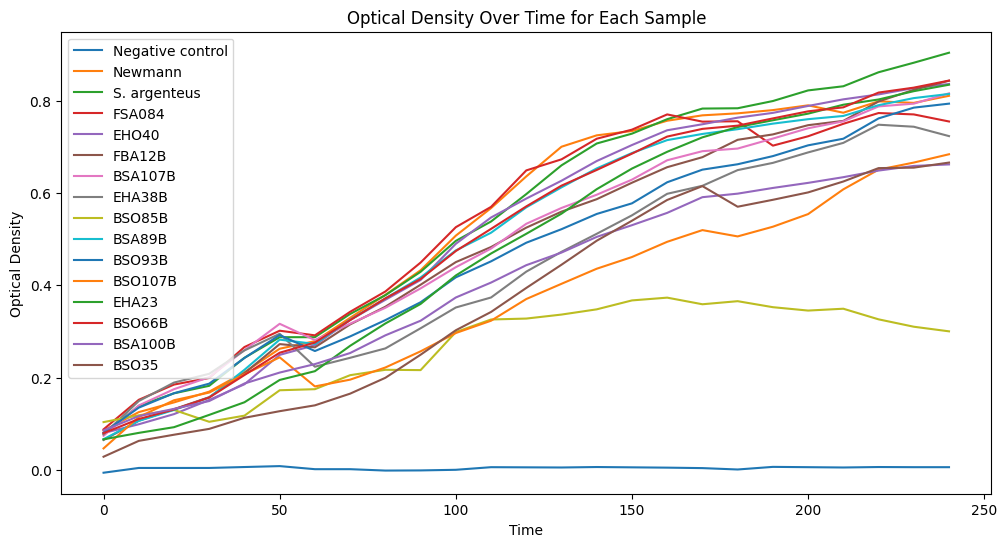

In [58]:
# 2. Plot Optical Density Over Time for Each Sample
plt.figure(figsize=(12, 6))
for column in df.columns[1:]:  # Skip the 'Time' column
    plt.plot(df['Time'], df[column], label=column)

plt.xlabel('Time')
plt.ylabel('Optical Density')
plt.title('Optical Density Over Time for Each Sample')
plt.legend()
plt.show()


In [59]:
def exponential_growth(t, a, b):
    return a * np.exp(b * t)

growth_rates = {}
for column in df.columns[1:]:
    try:
        # Fit the exponential curve
        params, _ = curve_fit(exponential_growth, df['Time'], df[column], p0=[1, 0.1])
        growth_rates[column] = params[1]  # b parameter is the growth rate
    except:
        growth_rates[column] = None  # In case of fitting errors

print("Growth Rates (per sample):")
print(growth_rates)

Growth Rates (per sample):
{'Negative control': 0.004560829492708291, 'Newmann': 0.005559895991341279, 'S. argenteus': 0.005976507517530079, 'FSA084': 0.005017796635103456, 'EHO40': 0.006032958909617409, 'FBA12B': 0.006228491313616736, 'BSA107B': 0.0057818746622477594, 'EHA38B': 0.006182839889961571, 'BSO85B': 0.003687676201510517, 'BSA89B': 0.005862582518727247, 'BSO93B': 0.006001910131905093, 'BSO107B': 0.006622515876609173, 'EHA23': 0.006801742495016061, 'BSO66B': 0.0060337954952646294, 'BSA100B': 0.005882436559776886, 'BSO35': 0.007207984133150187}


In [60]:
# 4. Statistical Summary
summary_stats = df.describe()
print("Summary Statistics for Optical Density:")
print(summary_stats)


Summary Statistics for Optical Density:
             Time  Negative control    Newmann  S. argenteus     FSA084  \
count   25.000000         25.000000  25.000000     25.000000  25.000000   
mean   120.000000          0.003933   0.533533      0.547427   0.531620   
std     73.598007          0.003262   0.261895      0.271593   0.238374   
min      0.000000         -0.006000   0.085333      0.078333   0.088000   
25%     60.000000          0.001667   0.279000      0.287667   0.301667   
50%    120.000000          0.005333   0.636000      0.597667   0.649000   
75%    180.000000          0.006000   0.772667      0.783667   0.750000   
max    240.000000          0.008333   0.810667      0.904000   0.773333   

           EHO40     FBA12B    BSA107B     EHA38B     BSO85B     BSA89B  \
count  25.000000  25.000000  25.000000  25.000000  25.000000  25.000000   
mean    0.519133   0.490040   0.496933   0.441880   0.265893   0.509053   
std     0.267333   0.247658   0.231969   0.214437   0.09756

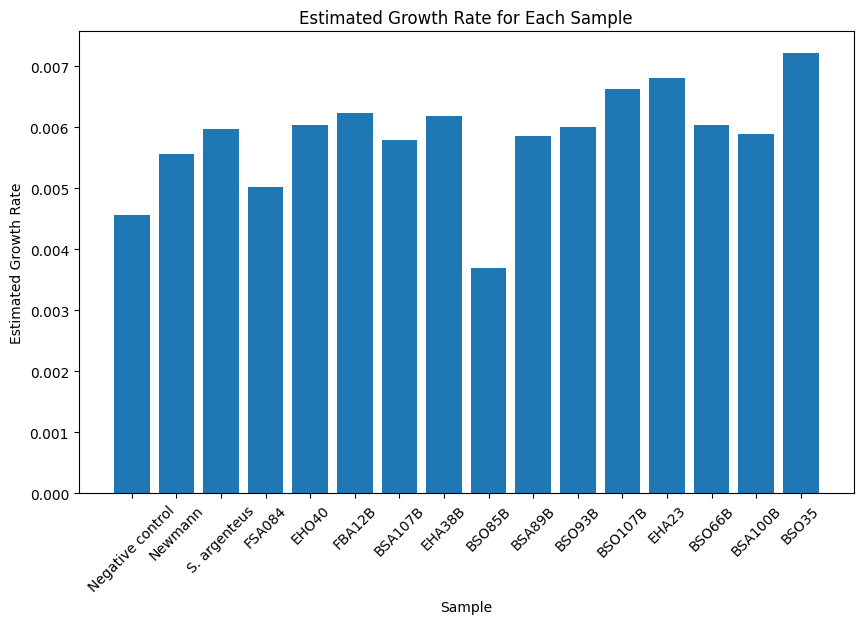

In [61]:

# Optional: Plot Growth Rates
plt.figure(figsize=(10, 6))
plt.bar(growth_rates.keys(), growth_rates.values())
plt.xlabel('Sample')
plt.ylabel('Estimated Growth Rate')
plt.title('Estimated Growth Rate for Each Sample')
plt.xticks(rotation=45)
plt.show()

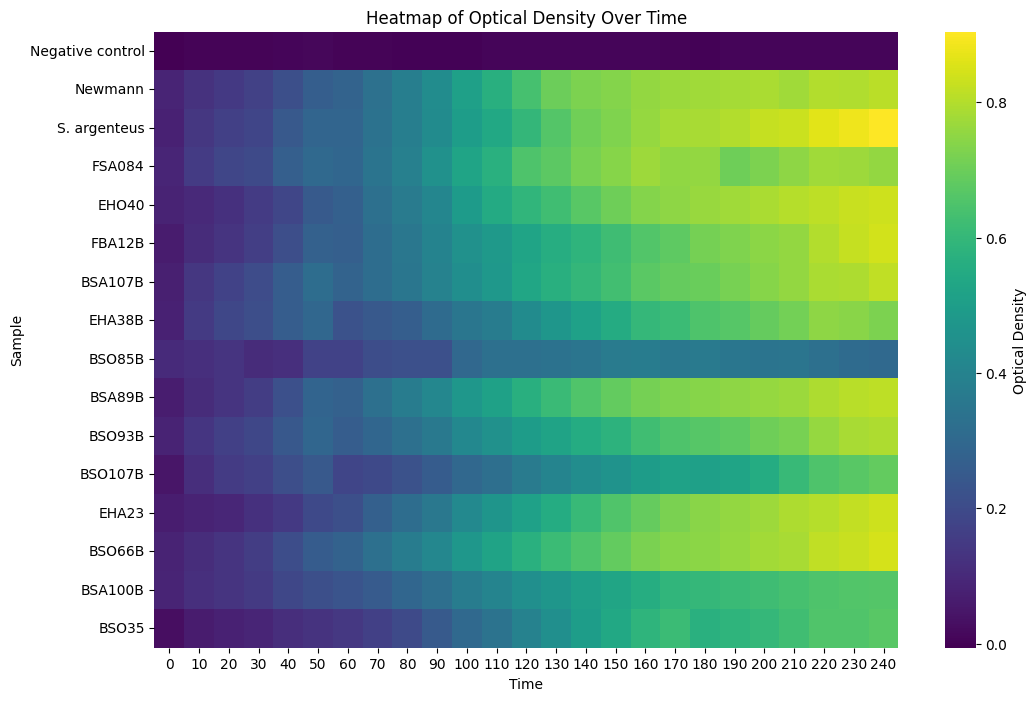

In [62]:
# 5. Heatmap of Optical Densities
plt.figure(figsize=(12, 8))
sns.heatmap(df.set_index('Time').T, cmap="viridis", cbar_kws={'label': 'Optical Density'})
plt.title("Heatmap of Optical Density Over Time")
plt.xlabel("Time")
plt.ylabel("Sample")
plt.show()


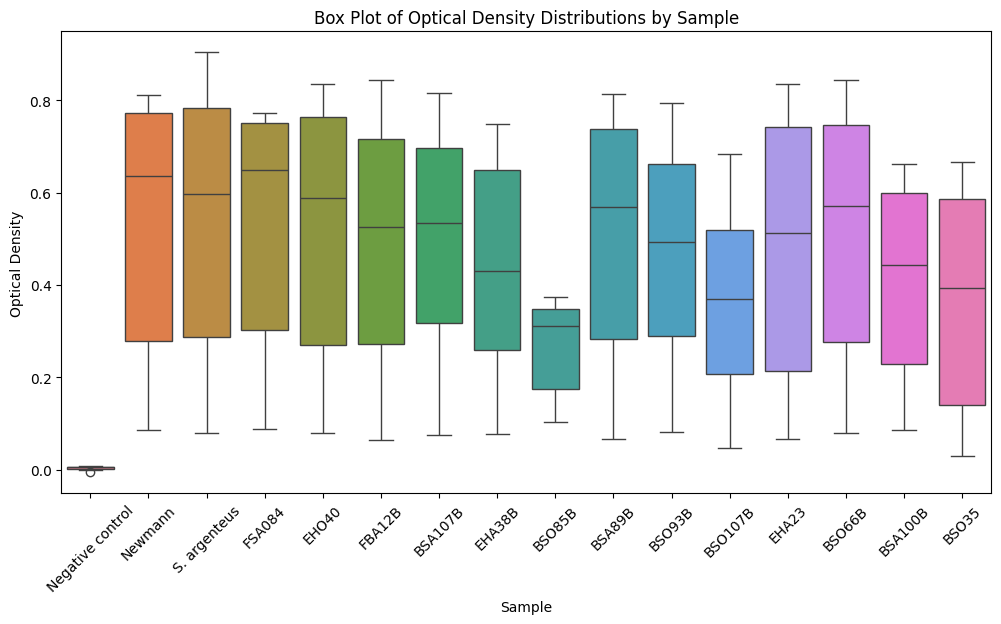

In [63]:
# 6. Box Plot of Optical Density Distributions
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.iloc[:, 1:])  # Exclude 'Time' column
plt.title("Box Plot of Optical Density Distributions by Sample")
plt.ylabel("Optical Density")
plt.xlabel("Sample")
plt.xticks(rotation=45)
plt.show()


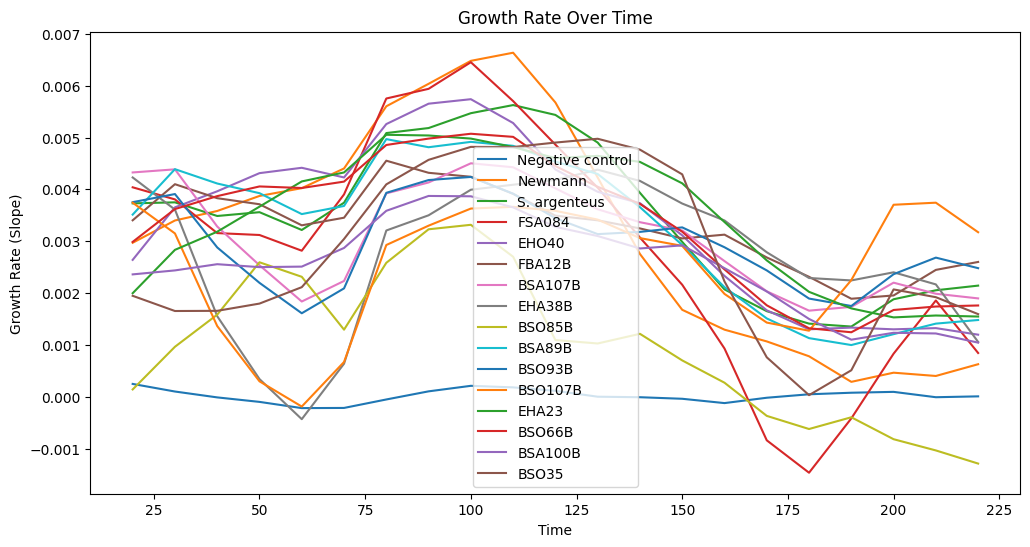

In [64]:
# 7. Growth Rate Over Time with Slope Analysis
from scipy.stats import linregress

window_size = 5  # Choose a window size for the rolling slope analysis
time = df['Time']

plt.figure(figsize=(12, 6))
for column in df.columns[1:]:
    slopes = []
    times = []
    # Calculate slope in each window
    for i in range(len(time) - window_size + 1):
        subset_time = time[i:i + window_size]
        subset_values = df[column][i:i + window_size]
        slope, _, _, _, _ = linregress(subset_time, subset_values)
        slopes.append(slope)
        times.append(np.mean(subset_time))  # Midpoint of time window

    plt.plot(times, slopes, label=column)

plt.xlabel("Time")
plt.ylabel("Growth Rate (Slope)")
plt.title("Growth Rate Over Time")
plt.legend()
plt.show()


In [65]:
# 8. Interactive Line Plot using Plotly
!pip install plotly
import plotly.express as px

df_long = pd.melt(df, id_vars=['Time'], var_name='Sample', value_name='Optical Density')
fig = px.line(df_long, x='Time', y='Optical Density', color='Sample',
              title="Optical Density Over Time (Interactive)")
fig.show()
